In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import numpy as np
from matplotlib.pyplot import plot

from utils.confusion import classification_report_suite, calculate_classification_metrics

data = pd.read_csv('./data/site_species_presence.csv')

## Base Line Logistic Regression Model
First base model. This is trained on: 
- Lattitude
- Longitude
- Watershed Area

With the target of cold water indicator species (sites that recorded >= 30 SS + EBT)

Note: Have not accounted for impervious terrain

**Results:**
Class 0 (Absent):
  - Precision 0.90 — When the model predicts a site is absent, it's right 90% of the time
  - Recall 0.79 — Of the 84 truly absent sites, it correctly identified 79% (~66 sites); it wrongly called 18 sites "present" when they weren't

Class 1 (Present):
  - Precision 0.56 — When the model predicts a site is present, it's only right 56% of the time (lots of false alarms)      
  - Recall 0.77 — Of the 30 truly present sites, it caught 77% (~23 sites); it missed 7 sites that actually had cold water species


Accuracy: 0.68
Precision: 0.44
Recall: 0.73
F1 Score: 0.55


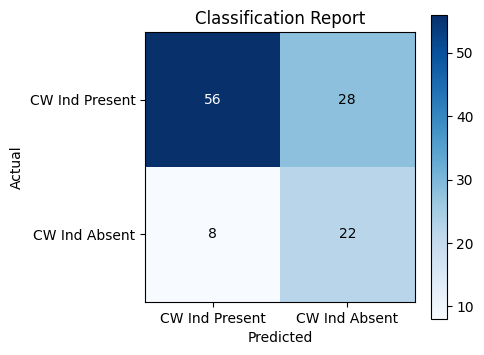

In [3]:
data.dropna(inplace=True)

x_train, x_test, y_train, y_test = train_test_split(data.drop(columns=['cw_ind', 'Unique_ID']), data['cw_ind'], test_size=0.2, random_state=42)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(x_train, y_train)

test = log_reg.predict(x_test)

classification_report_suite(y_test, test, labels=['CW Ind Present', 'CW Ind Absent'], title='Classification Report')

## Logistic Regression Base Line W/ No Fish Observation Data
This is the same as the above model but it excludes the presence/absence of all species of fish. 

Accuracy: 0.78
Precision: 0.56
Recall: 0.77
F1 Score: 0.65


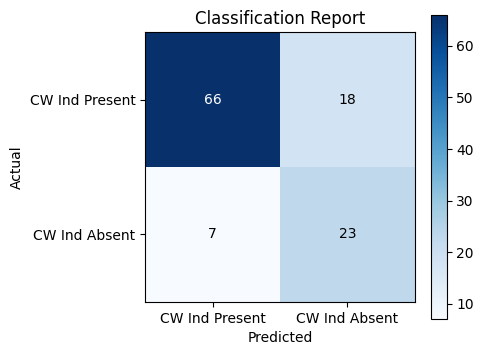

In [5]:
data.dropna(inplace=True)
no_fish_data = data[["latitude", "longitude", "watershed_area", "cw_ind"]]

x_train, x_test, y_train, y_test = train_test_split(no_fish_data.drop(columns=['cw_ind']), data['cw_ind'], test_size=0.2, random_state=42)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(x_train, y_train)

test = log_reg.predict(x_test)

classification_report_suite(y_test, test, labels=['CW Ind Present', 'CW Ind Absent'], title='Classification Report')

## Selecting Observation Sites by Human Involvement

As a first attempt at deciding what sites should be removed from the model based on how much human involvement is present in their watershed we created logistic regression models that train with sites removed that had >= 3%, 5%, 7%, 10%, and 15% impervious land coverage.

The full dataset is split into training, validation, and testing data prior to each model being trained. This way we can exclude the observations we want to while also testing across all data regardless of human involvement. Allowing us to compare each model against the same data. We perform cross validation over models by leaving out observations beyond each threshold (1-2 by 0.1 increments) and compare their classification scores. Comparison is done using the F1-score so as to balance precision and recall. Then we test the best performing model on the test set. 

<= 1.0% | train n=210 | val F1=0.451  P=0.356  R=0.615
<= 1.1% | train n=225 | val F1=0.466  P=0.362  R=0.654
<= 1.2% | train n=236 | val F1=0.514  P=0.409  R=0.692
<= 1.3% | train n=243 | val F1=0.514  P=0.409  R=0.692
<= 1.4% | train n=250 | val F1=0.514  P=0.409  R=0.692
<= 1.5% | train n=252 | val F1=0.514  P=0.409  R=0.692
<= 1.6% | train n=257 | val F1=0.514  P=0.409  R=0.692
<= 1.7% | train n=260 | val F1=0.514  P=0.409  R=0.692
<= 1.8% | train n=265 | val F1=0.507  P=0.400  R=0.692
<= 1.9% | train n=266 | val F1=0.507  P=0.400  R=0.692
<= 2.0% | train n=269 | val F1=0.507  P=0.400  R=0.692

Best threshold on validation: <= 1.2% (F1=0.514)
Evaluating best threshold on held-out test set:

=== Best model: pct_impervious <= 1.2% | trained on n=320, tested on n=114 ===
Accuracy: 0.82
Precision: 0.64
Recall: 0.70
F1 Score: 0.67


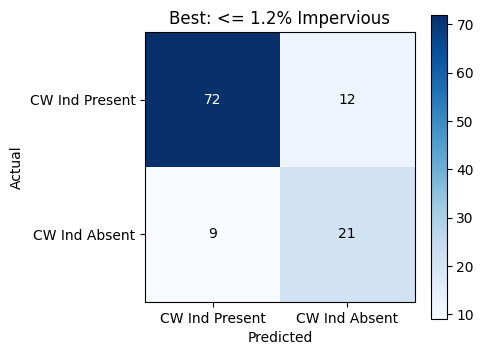

In [17]:
full = data.dropna(subset=['latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_imperviousness'])

features = ['latitude', 'longitude', 'watershed_area']
target = 'cw_ind'
thresholds = [round(x, 1) for x in np.arange(1.0, 2.1, 0.1)]

train_full, test_full = train_test_split(full, test_size=0.2, random_state=42)
train_split, val_split = train_test_split(train_full, test_size=0.25, random_state=42)

X_val = val_split[features]
y_val = val_split[target]
X_test = test_full[features]
y_test = test_full[target]

best_pct = None
best_f1 = -1

for pct in thresholds:
    train_subset = train_split[train_split['pct_imperviousness'] <= pct]
    X_train = train_subset[features]
    y_train = train_subset[target]

    if len(y_train.unique()) < 2:
        print(f"=== pct_impervious <= {pct}% | skipped — only one class in training (n={len(train_subset)}) ===\n")
        continue

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    _, precision, recall, f1 = calculate_classification_metrics(y_val, y_val_pred)

    print(f"<= {pct}% | train n={len(train_subset)} | val F1={f1:.3f}  P={precision:.3f}  R={recall:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_pct = pct

print(f"\nBest threshold on validation: <= {best_pct}% (F1={best_f1:.3f})")
print("=" * 60)
print("Evaluating best threshold on held-out test set:\n")

best_subset = train_full[train_full['pct_imperviousness'] <= best_pct]
X_train_final = best_subset[features]
y_train_final = best_subset[target]

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
final_model.fit(X_train_final, y_train_final)
y_test_pred = final_model.predict(X_test)

print(f"=== Best model: pct_impervious <= {best_pct}% | trained on n={len(best_subset)}, tested on n={len(test_full)} ===")
classification_report_suite(y_test, y_test_pred, labels=['CW Ind Present', 'CW Ind Absent'], title=f'Best: <= {best_pct}% Impervious')